In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import gymnasium as gym
import os
import sys
from typing import List, Any
import time

# Add project root to path for imports
script_path = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(script_path, "..", "..", ".."))
algorithms_dir = os.path.join(project_root, "causalgym", "causal_gym", "algorithms")

if project_root not in sys.path:
    sys.path.insert(0, project_root)
if algorithms_dir not in sys.path:
    sys.path.insert(0, algorithms_dir)

from causal_gym.envs.lunar_lander import LunarLanderPCH
from ucbvi import UCBVI

In [2]:
class Discretiser:
    """Discretises continuous observation space for LunarLander-v2 into integer states."""
    def __init__(self, obs_low: np.ndarray, obs_high: np.ndarray, bins_per_dim: List[int]):
        self.obs_low = obs_low
        self.obs_high = obs_high
        self.bins_per_dim = np.array(bins_per_dim, dtype=np.int_)
        self.num_dims = len(bins_per_dim)

        self.bin_edges = []
        for i in range(self.num_dims):
            edges = np.linspace(self.obs_low[i], self.obs_high[i], self.bins_per_dim[i] + 1)
            self.bin_edges.append(edges)

        self._n_states = np.prod(self.bins_per_dim)

    def __call__(self, obs: np.ndarray) -> int:
        bin_indices = np.empty(self.num_dims, dtype=np.int_)
        for i in range(self.num_dims):
            clipped_obs_i = np.clip(obs[i], self.obs_low[i], self.obs_high[i])
            if self.bins_per_dim[i] == 1:
                bin_indices[i] = 0
            else:
                thresholds = self.bin_edges[i][1:-1]
                bin_indices[i] = np.digitize(clipped_obs_i, thresholds)
        
        state_index = 0
        for i in range(self.num_dims):
            state_index = state_index * self.bins_per_dim[i] + bin_indices[i]
        return int(state_index)

    @property
    def n_states(self) -> int:
        return self._n_states

# Test the Discretiser
temp_gym_env = gym.make("LunarLander-v3")
obs_low = temp_gym_env.observation_space.low
obs_high = temp_gym_env.observation_space.high
temp_gym_env.close()

# Using reduced state space for UCBVI
lander_bins_config = [3, 3, 2, 2, 3, 2, 2, 2]  # 864 states
discretiser = Discretiser(obs_low, obs_high, lander_bins_config)

print(f"Testing Discretiser with configuration: {lander_bins_config}")
print(f"Total number of states: {discretiser.n_states}")
test_obs = np.zeros(8)
test_state = discretiser(test_obs)
print(f"Test observation {test_obs} -> state index: {test_state}")

Testing Discretiser with configuration: [3, 3, 2, 2, 3, 2, 2, 2]
Total number of states: 864
Test observation [0. 0. 0. 0. 0. 0. 0. 0.] -> state index: 468


In [3]:
# Training parameters
config = {
    "episodes": 500,
    "horizon": 1000,
    "delta": 0.1,
    "seed": 42
}

print("Training Configuration:")
for key, value in config.items():
    print(f"{key}: {value}")

# Initialize environment and agent
np.random.seed(config["seed"])
env = LunarLanderPCH()
n_actions = env.action_space.n

agent = UCBVI(
    num_states=discretiser.n_states,
    n_actions=n_actions,
    horizon=config["horizon"],
    delta=config["delta"],
    seed=config["seed"]
)

print(f"\nEnvironment initialized with {n_actions} actions")
print(f"State space discretized into {discretiser.n_states} states")

Training Configuration:
episodes: 500
horizon: 1000
delta: 0.1
seed: 42

Environment initialized with 4 actions
State space discretized into 864 states


In [4]:
returns = []
successful_landings = []

print(f"Starting training for {config['episodes']} episodes...")
start_time = time.time()

for ep in range(config['episodes']):
    obs_continuous, _ = env.reset(seed=config['seed'] + ep)
    s = discretiser(obs_continuous)
    ep_return = 0.0
    
    for t in range(config['horizon']):
        x_intended = np.argmax(agent.V[s, :])
        a_to_apply = agent.act(s, x_intended)
        
        obs2_continuous, r, terminated, truncated, info = env.step(a_to_apply)
        s2 = discretiser(obs2_continuous)
        done = terminated or truncated
        
        agent.update(s, x_intended, a_to_apply, r, s2)
        ep_return += r
        
        if terminated and r >= 100:
            successful_landings.append(ep)
            print(f"Ep {ep+1:4d}, Step {t+1}: SUCCESSFUL LANDING! Reward: {r:.2f}, Total Return: {ep_return:.2f}")
        
        if done:
            break
            
        s = s2
    
    returns.append(ep_return)
    
    if (ep + 1) % max(1, config['episodes'] // 10) == 0:
        print(f"Episode {ep+1:4d}/{config['episodes']} | Return: {ep_return:7.2f} | Steps: {t+1}")

env.close()
training_time = time.time() - start_time
print(f"\nTraining completed in {training_time:.2f} seconds")

# Calculate performance statistics
if config['episodes'] >= 20:
    num_slice = config['episodes'] // 10
    avg_return_first_10_percent = np.mean(returns[:num_slice])
    avg_return_last_10_percent = np.mean(returns[-num_slice:])
    print(f"\nPerformance Statistics:")
    print(f"Average return of first {num_slice} episodes: {avg_return_first_10_percent:.2f}")
    print(f"Average return of last {num_slice} episodes: {avg_return_last_10_percent:.2f}")
    print(f"Total successful landings: {len(successful_landings)}")

Starting training for 500 episodes...
  UCBVI.update: s=560, x_int=0, a_exec=3, r=0.31, s'=560
    N[560,0,3]=1.0->2.0, R[560,0,3]=0.00->0.16
  UCBVI.update: s=560, x_int=0, a_exec=0, r=0.92, s'=560
    N[560,0,0]=1.0->2.0, R[560,0,0]=0.00->0.46
  UCBVI.update: s=560, x_int=0, a_exec=3, r=0.33, s'=560
    N[560,0,3]=2.0->3.0, R[560,0,3]=0.16->0.21
  UCBVI.update: s=560, x_int=0, a_exec=0, r=0.49, s'=560
    N[560,0,0]=2.0->3.0, R[560,0,0]=0.46->0.47
  UCBVI.update: s=560, x_int=0, a_exec=0, r=0.46, s'=560
    N[560,0,0]=3.0->4.0, R[560,0,0]=0.47->0.47
  UCBVI.update: s=560, x_int=0, a_exec=1, r=0.96, s'=560
    N[560,0,1]=1.0->2.0, R[560,0,1]=0.00->0.48
  UCBVI.update: s=560, x_int=0, a_exec=0, r=0.14, s'=560
    N[560,0,0]=4.0->5.0, R[560,0,0]=0.47->0.40
  UCBVI.update: s=560, x_int=0, a_exec=1, r=0.03, s'=560
    N[560,0,1]=2.0->3.0, R[560,0,1]=0.48->0.33
  UCBVI.update: s=560, x_int=0, a_exec=1, r=0.15, s'=560
    N[560,0,1]=3.0->4.0, R[560,0,1]=0.33->0.28
  UCBVI.update: s=440, x_i

Plot saved as plots/lander_ucbvi_returns.png


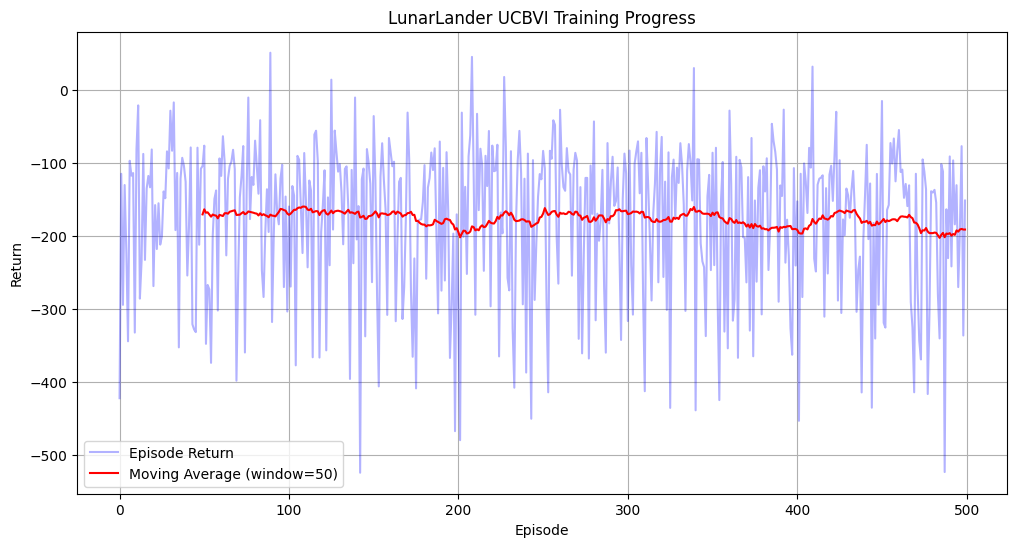

In [5]:
plt.figure(figsize=(12, 6))

# Plot episode returns
plt.plot(returns, 'b-', alpha=0.3, label='Episode Return')

# Calculate and plot moving average
window_size = min(50, len(returns) // 10)
if window_size >= 2:
    moving_avg = np.convolve(returns, np.ones(window_size)/window_size, mode='valid')
    moving_avg_x = np.arange(window_size-1, len(returns))
    plt.plot(moving_avg_x, moving_avg, 'r-', label=f'Moving Average (window={window_size})')

plt.xlabel('Episode')
plt.ylabel('Return')
plt.title('LunarLander UCBVI Training Progress')
plt.grid(True)
plt.legend()

# Save the plot
plots_dir = "plots"
if not os.path.exists(plots_dir):
    os.makedirs(plots_dir)
plot_filename = os.path.join(plots_dir, "lander_ucbvi_returns.png")
plt.savefig(plot_filename)
print(f"Plot saved as {plot_filename}")
plt.show()

In [6]:
# Create environment for visualization
gif_env = LunarLanderPCH(render_mode="rgb_array")
frames = []

obs_gif, _ = gif_env.reset(seed=config['seed'] + config['episodes'] + 1)
s_gif = discretiser(obs_gif)
ep_return_gif = 0.0

for step_gif in range(config['horizon']):
    frame = gif_env.render()
    if frame is not None:
        frames.append(frame)
    
    x_intended_gif = np.argmax(agent.V[s_gif, :])
    a_to_apply_gif = agent.act(s_gif, x_intended_gif)
    
    obs2_gif, r_gif, terminated_gif, truncated_gif, _ = gif_env.step(a_to_apply_gif)
    s2_gif = discretiser(obs2_gif)
    s_gif = s2_gif
    ep_return_gif += r_gif
    
    if terminated_gif and r_gif >= 100:
        print(f"GIF Rollout: SUCCESSFUL LANDING! Final Return: {ep_return_gif:.2f}")
    
    if terminated_gif or truncated_gif:
        break

gif_env.close()
print(f"GIF rollout complete | Return: {ep_return_gif:.2f} | Steps: {step_gif+1}")

if frames:
    # Save the animation
    fig = plt.figure(figsize=(8, 8))
    plt.axis('off')
    patch = plt.imshow(frames[0])
    
    def animate_fn(i):
        patch.set_data(frames[i])
        return patch,

    anim = animation.FuncAnimation(
        fig, animate_fn, frames=len(frames),
        interval=50, blit=True
    )
    
    gif_filename = os.path.join(plots_dir, "lander_rollout.gif")
    anim.save(gif_filename, writer="pillow", fps=20)
    print(f"Animation saved as {gif_filename}")
    plt.close()

GIF rollout complete | Return: -68.56 | Steps: 61
Animation saved as plots/lander_rollout.gif
